In [1]:
import json
import shapely
from datetime import datetime, timedelta
import pytz
import pystac_client

import nestedgrid
import stac_hsi

# STAC collections

In [3]:
STAC_URL="http://stac-fastapi-sqlalchemy-geodn-discovery.cimf-dev-9ca4d14d48413d18ce61b80811ba4308-0000.us-south.containers.appdomain.cloud/"

In [4]:
stac = pystac_client.Client.open(STAC_URL)
stac_collections = list(stac.get_all_collections())
stac_collections

[<CollectionClient id=ibm-eis-ga-1-esa-sentinel-2-l2a>,
 <CollectionClient id=HLSL30>,
 <CollectionClient id=Global weather (ERA5)>,
 <CollectionClient id=TWC Seasonal Weather Forecast>,
 <CollectionClient id=HLSS30>,
 <CollectionClient id=Historical crop planting map (USA)>,
 <CollectionClient id=sentinel2-10m-lulc>,
 <CollectionClient id=HSI - HLSS30>,
 <CollectionClient id=HSI - HLSL30>,
 <CollectionClient id=HSI - Historical crop planting map (USA)>]

# Access HLS through STAC

In [5]:
%%time
# STAC search Parameters
collection_id = 'HLSS30'

# Bounding box around Kenya
west = 33
south = -5
east = 42
north = 6
poly = shapely.box(west, south, east, north)
search_aoi = json.loads(shapely.to_geojson(poly))

year = 2022 #None 
month = None #1

# Search the available raw data in stac
search_items = stac_hsi.stac_search_available(
    STAC_URL,
    collection_id,
    search_aoi,
    year = year,
    month = month,
    fields = None,
    filter_band = None,
    filter_crs = None, #DEBUG, DOES NOT WORK YET SINCE RAW DATA HAS WRONG CRS
    verbose = True,
)

search_items[0]

dt_string 2022-01-01T00:00:00Z/2022-12-31T23:59:59Z
search_aoi {'type': 'Polygon', 'coordinates': [[[42.0, -5.0], [42.0, 6.0], [33.0, 6.0], [33.0, -5.0], [42.0, -5.0]]]}
batch 0 ; raw      10000
batch 0 ; filtered 10000
batch 1 ; raw      4168
batch 1 ; filtered 4168
Found 14168 search items
CPU times: user 8.24 s, sys: 484 ms, total: 8.73 s
Wall time: 28.5 s


id: HLS.S30.T36NXK.2022364T080239.v2.0.B01
"bbox: [33.9014269, 3.528653, 34.8886351, 4.5233632]"
datetime: 2022-12-30T08:02:39+00:00
tile: T36NXK
cloud_coverage: 20
"cube:variables: {'B01': {'type': 'data', 'unit': '', 'values': [], 'dimensions': ['x', 'y', 'time']}}"
"cube:dimensions: {'x': {'axis': 'x', 'step': 30.0, 'type': 'spatial', 'extent': [600000.0, 709800.0], 'reference_system': 4326}, 'y': {'axis': 'y', 'step': -30.0, 'type': 'spatial', 'extent': [500040.0, 390240.0], 'reference_system': 4326}, 'time': {'type': 'temporal', 'extent': ['2022-12-30T08:02:39Z', '2022-12-30T08:18:55Z']}}"
href: s3://fm-geospatial-cos-standard-poc/lchu/HLSS30/la+39017+41504lo+342718+345194/2022/12/HLS.S30.T36NXK.2022364T080239.v2.0.B01.tif
type: image/tiff; application=geotiff; profile=cloud-optimized
title: B01
roles: ['data']


# Use the asset href to access HLS GeoTiffs the usual way

In [6]:
search_items[0].assets['data'].href

's3://fm-geospatial-cos-standard-poc/lchu/HLSS30/la+39017+41504lo+342718+345194/2022/12/HLS.S30.T36NXK.2022364T080239.v2.0.B01.tif'

# Querying the HSI using STAC search

In [7]:
collection_id = 'HSI - HLSS30'
# collection = stac_collections[[c.id for c in stac_collections].index(collection_id)]
# collection

In [8]:
utm_zone = '37N' #'10N'
grid = nestedgrid.UTM30m_North(utm_zone)
crs = int(grid.crs.split(':')[1])
print('crs', crs)
#morton = mortoncurve.Morton(grid)

# def valid_bounds_to_wgs84(grid):
#     gdf = geopandas.GeoDataFrame([{'geometry': shapely.box(*grid.valid_bounds)}]).set_crs(grid.crs).to_crs('4326')
#     return gdf.loc[0, 'geometry']
# print(valid_bounds_to_wgs84(grid))

vars(grid)

crs 32637


{'north_or_south': 'north',
 'zone_number': 37,
 'crs': 'EPSG:32637',
 'origin': Origin(x=0.0, y=-15728640),
 'res0': Res0(x=31457280, y=31457280),
 'level0_bounds': [0.0, -15728640, 31457280.0, 15728640],
 'max_levels': 29,
 'epsilon': 1e-07,
 'valid_bounds_wgs84': [36, -80, 42, 84],
 'valid_bounds': [166021.44, -8883084.96, 833978.56, 9329005.18]}

In [9]:
%%time
## Search Parameters
collection_id = 'HSI - HLSS30'
LIMIT = 10000

search_aoi = json.loads(shapely.to_geojson(shapely.box(*grid.valid_bounds_wgs84)))
west, south, east, north = grid.valid_bounds_wgs84
print('west, south, east, north', west, south, east, north)
search_aoi = json.loads(shapely.to_geojson(shapely.box(west, south, east, north)))

# year = 2020
# month = 8

if month is None:
    dt_start = datetime(year, 1, 1)
    dt_end = (datetime(year+1, 1, 1)-timedelta(seconds=1))
else:
    dt_start = datetime(year, month, 1)
    if month<12:
        dt_end = (datetime(year, month+1, 1)-timedelta(seconds=1))
    elif month==12:
        dt_end = (datetime(year+1, 1, 1)-timedelta(seconds=1))
    else:
        raise ValueError

ISO_8601 = '%Y-%m-%dT%H:%M:%SZ'
dt_string = None
if dt_start is not None:
    dt_string = dt_start.strftime(ISO_8601)

    if dt_end is not None:
        dt_string = dt_string + '/' + dt_end.strftime(ISO_8601)
print('dt_string', dt_string)

fields = {
    "include": [
        "id",
        "bbox",
        "datetime",
        "properties.table:columns",
        "properties.tile",
        "properties.cube:variables",
        "properties.cube:dimensions",
        "properties.proj:epsg",
        "properties.proj:bbox",
        "properties.proj:geometry",
        "properties.cloud_coverage",
    ],
    "exclude": [
    ],
}

# pystac_client search
stac_search_result = stac.search(
    limit = LIMIT,
    collections = [collection_id],
    intersects = search_aoi,
    datetime = dt_string,
    fields = fields,
    query = {"proj:epsg": {"eq": crs}},
)
search_items = next(stac_search_result.pages())
print('Found', len(search_items), 'search items')

# Filter by the STAC-informed reference_system
search_items = [item for item in search_items if f"EPSG:{str(item.properties['proj:epsg'])}"==grid.crs]

# Filtering bands
#search_items = [item for item in search_items if 'Fmask' in item.properties['cube:dimensions']['dimension_band']['extent']]

print('Found', len(search_items), 'filtered items')
search_items[0]

west, south, east, north 36 -80 42 84
dt_string 2022-01-01T00:00:00Z/2022-12-31T23:59:59Z
Found 84 search items
Found 84 filtered items
CPU times: user 192 ms, sys: 7.68 ms, total: 199 ms
Wall time: 1.29 s


id: 0b23dbd0a2b2407ab1a74705cffb6b75
"bbox: [37.197288422861696, 1.7188523681456116, 38.190138619590954, 2.2232330950124313]"
datetime: 2022-12-04T07:42:09+00:00
"proj:bbox: [299520.0, 190080.0, 409919.9999999, 245759.9999999]"
"cube:dimensions: {'time': {'step': None, 'type': 'temporal', 'extent': ['2022-12-04T07:42:09Z', '2022-12-29T07:43:21Z'], 'description': None}, 'q_key': {'axis': 'q_key', 'step': None, 'type': 'spatial', 'extent': None, 'description': 'base4 key of the Morton curve', 'reference_system': None}, 'dimension_band': {'axis': 'dimension_band', 'step': None, 'type': 'other', 'extent': ['Fmask'], 'description': None, 'reference_system': None}, 'dimension_tile': {'axis': 'dimension_tile', 'step': None, 'type': 'other', 'extent': ['T37NCC'], 'description': None, 'reference_system': None}, 'dimension_product': {'axis': 'dimension_product', 'step': None, 'type': 'other', 'extent': ['S30'], 'description': None, 'reference_system': None}}"
"proj:geometry: {'type': 'Polygon', 'coordinates': [[[409919.9999999, 190080.0], [409919.9999999, 245759.9999999], [299520.0, 245759.9999999], [299520.0, 190080.0], [409919.9999999, 190080.0]]]}"
proj:epsg: 32637
href: s3://fm-geospatial-cos-standard-poc/hsi/hlss/crs=32637/overview_level=15/year=2022/month=12/spatial_partition=0q2000001/overview.parquet
type: table/parquet; application=geoparquet; profile=cloud-optimized
title: HSI - HLSS30
roles: ['hierarchical spatial index']


# Use the asset href to access HSI parquet files the usual way

In [10]:
search_items[0].assets['data'].href

's3://fm-geospatial-cos-standard-poc/hsi/hlss/crs=32637/overview_level=15/year=2022/month=12/spatial_partition=0q2000001/overview.parquet'

# Load the HSI data to memory

In [11]:
%%time
## Search Parameters
collection_id = 'HLSS30'
hsi_collection_id = 'HSI - ' + collection_id
hsi_collection_id

west = -180
east = 180
south = -90
north = 90

search_aoi = {'type': 'Polygon', 'coordinates': [[
    [west, south], 
    [east, south], 
    [east, north], 
    [west, north], 
    [west, south], 
]]}

dt_start = datetime(year, 1, 1, tzinfo=pytz.utc)
dt_end = (datetime(year+1, 1, 1, tzinfo=pytz.utc)-timedelta(seconds=1))

#filter_col = 'count_111' # open water
#filter_col = 'count_2' # Cotton
#filter_col = 'count_75' # Almonds
filter_col = None

filters = [
    #(filter_col, '>', 0),
    #(filter_col, '>', 2**14/2), # Fraction > 50%
    #(filter_col, '>', 2**14/100),
]

required_crs = int(grid.crs.split(':')[1])

fields = {
    "include": [
        "id",
        "bbox",
        "datetime",
        "properties.table:columns",
        "properties.proj:epsg",
        #"properties.tile",
        #"properties.cube:variables",
        #"properties.cube:dimensions",
        #"properties.cloud_coverage",
    ],
    "exclude": [
    ],
}

#columns = None
columns = None #['q_key', 'timestamp', 'geometry', 'top', filter_col]

gdf_hsi = stac_hsi.search_hsi(
    stac,
    service_credentials,
    endpoint_url,
    hsi_collection_id,
    search_aoi=search_aoi,
    dt_start=dt_start,
    dt_end=dt_end,
    fields=fields,
    #required_cols=[filter_col],
    filters=filters,
    required_crs=required_crs,
    columns=columns,
    limit=None,
    verbose=True,
)

gdf_hsi.tail(2)

limit              200
hsi_collection_id  HSI - HLSS30
dt_string          2022-01-01T00:00:00Z/2022-12-31T23:59:59Z
Found 168 search items
Found 84 search items
filters           [,
    ('time', '>=', datetime.datetime(2022, 1, 1, 0, 0, tzinfo=<UTC>)),
    ('time', '<=', datetime.datetime(2022, 12, 31, 23, 59, 59, tzinfo=<UTC>))
]
columns            None
CPU times: user 40.5 s, sys: 5min 17s, total: 5min 57s
Wall time: 5min 56s


,q_key,geometry,dimension_product,dimension_band,dimension_tile,time,count,unique,top,freq,...,count_80,count_84,count_96,count_100,count_240,count_244,count_112,count_176,count_180,count_116
6316887,0q022223231131332,"POLYGON ((735360.000 -100800.000, 735360.000 -...",S30,Fmask,T37MGU,2022-01-27 07:21:51+00:00,896,4,128,624,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
6316888,0q022223231131333,"POLYGON ((736320.000 -100800.000, 736320.000 -...",S30,Fmask,T37MGU,2022-01-27 07:21:51+00:00,896,11,196,314,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN


In [12]:
gdf_unique = gdf_hsi.drop_duplicates(subset='q_key').reset_index(drop=True)
gdf_unique.tail(2)

,q_key,geometry,dimension_product,dimension_band,dimension_tile,time,count,unique,top,freq,...,count_80,count_84,count_96,count_100,count_240,count_244,count_112,count_176,count_180,count_116
73308,0q022223231103122,"POLYGON ((718080.000 -112320.000, 718080.000 -...",S30,Fmask,T37MGU,2022-06-26 07:16:31+00:00,48,1,66,48,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN
73309,0q022223231121310,"POLYGON ((720000.000 -103680.000, 720000.000 -...",S30,Fmask,T37MGU,2022-06-26 07:16:31+00:00,40,1,66,40,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN


# Fmask cloudfree mosaic

In [15]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

In [16]:
mask = 0b00001110
all_codes = [int(c.strip('count_')) for c in gdf_hsi.columns if c.startswith('count_')]
noncloud_codes = ['count_' + str(x) for x in all_codes if (x & mask)==0]
cloud_codes = ['count_' + str(x) for x in all_codes if (x & mask)!=0]
gdf_hsi['sum_cloudfree'] = gdf_hsi[noncloud_codes].sum(axis=1)
gdf_hsi['sum_cloudy'] = gdf_hsi[cloud_codes].sum(axis=1)

cloudfree 32x32 pixel patches (total)  178606
cloudfree 32x32 pixel patches (unique) 70059


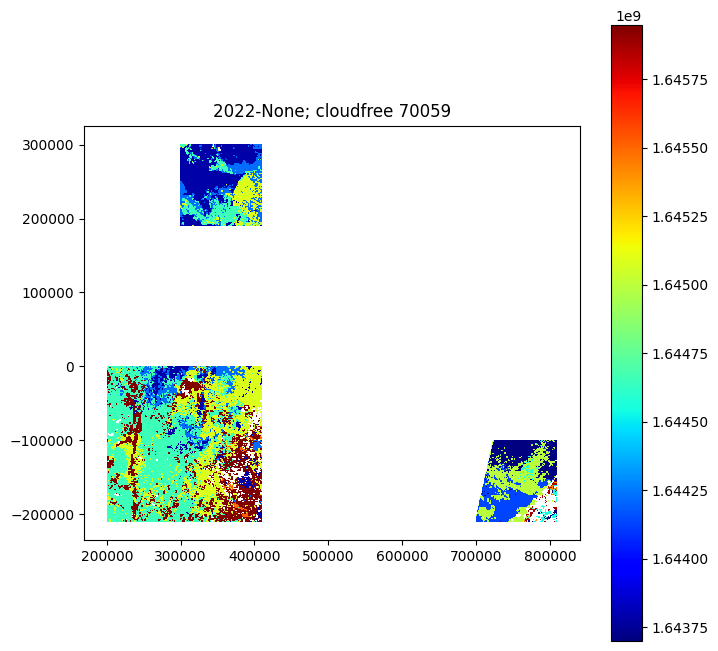

In [17]:
my_year = 2022
my_month = 2
gdf_year = gdf_hsi[gdf_hsi['time'].dt.year == my_year]
gdf_month = gdf_year[gdf_year['time'].dt.month == my_month]
gdf_cloudy = gdf_month[gdf_month['sum_cloudy']==gdf_month['count']]
gdf_cloudfree = gdf_month[gdf_month['sum_cloudfree']==gdf_month['count']]
print('cloudfree 32x32 pixel patches (total) ', len(gdf_cloudfree))
# gdf_ok = gdf_month[gdf_month['sum_cloudfree']>gdf_month['count']/2]
# print('ok clouds 32x32 pixel patches (total) ', len(gdf_ok))
gdf_plot = gdf_cloudfree
if len(gdf_plot)>0:
    #gdf_plot = gdf_plot.sample(frac=1)                           # frac=1 means random sampling
    #gdf_plot = gdf_plot.sort_values(by='time', ascending=False)  # Last cloudfree timestamp
    gdf_plot = gdf_plot.sort_values(by='time', ascending=True)  # First cloudfree timestamp
    gdf_plot = gdf_plot.drop_duplicates(subset=['q_key']).reset_index(drop=True)
    print('cloudfree 32x32 pixel patches (unique)', len(gdf_plot))
    ax = gdf_plot.plot(
        gdf_plot['time'].apply(lambda x: x.timestamp()),
        cmap='jet', legend=True, figsize=(8,8)
    )
    ax.set_aspect('equal')
    plt.title(str(year) + '-' + str(month) + '; cloudfree ' + str(len(gdf_plot)))
    plt.show()

In [18]:
gdf_plot.T

,0,1,2,3,4,5,6,7,8,9,...,70049,70050,70051,70052,70053,70054,70055,70056,70057,70058
q_key,0q022223302220132,0q022223213332020,0q022223213332021,0q022223213332022,0q022223213332023,0q022223213332030,0q022223213332031,0q022223213332032,0q022223213332033,0q022223213332100,...,0q022222303030231,0q022222303012023,0q022222303012022,0q022222303012020,0q022222303012200,0q022222303012202,0q022222303012201,0q022222303020031,0q022222303020013,0q022222303020011
geometry,"POLYGON ((743040 -135360, 743040 -134400.00000...","POLYGON ((721920 -128640, 721920 -127680.00000...","POLYGON ((722880 -128640, 722880 -127680.00000...","POLYGON ((721920 -127680, 721920 -126720.00000...","POLYGON ((722880 -127680, 722880 -126720.00000...","POLYGON ((723840 -128640, 723840 -127680.00000...","POLYGON ((724800 -128640, 724800 -127680.00000...","POLYGON ((723840 -127680, 723840 -126720.00000...","POLYGON ((724800 -127680, 724800 -126720.00000...","POLYGON ((725760 -130560, 725760 -129600.00000...",...,"POLYGON ((325440 -163200, 325440 -162240.00000...","POLYGON ((323520 -173760, 323520 -172800.00000...","POLYGON ((322560 -173760, 322560 -172800.00000...","POLYGON ((322560 -174720, 322560 -173760.00000...","POLYGON ((322560 -172800, 322560 -171840.00000...","POLYGON ((322560 -171840, 322560 -170880.00000...","POLYGON ((323520 -172800, 323520 -171840.00000...","POLYGON ((310080 -167040, 310080 -166080.00000...","POLYGON ((310080 -168000, 310080 -167040.00000...","POLYGON ((310080 -168960, 310080 -168000.00000..."
dimension_product,S30,S30,S30,S30,S30,S30,S30,S30,S30,S30,...,S30,S30,S30,S30,S30,S30,S30,S30,S30,S30
dimension_band,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,...,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask,Fmask
dimension_tile,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,T37MGU,...,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU,T37MCU
time,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,2022-02-01 07:21:19+00:00,...,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00,2022-02-27 07:38:49+00:00
count,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,...,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024
unique,2,2,2,2,2,2,2,2,2,1,...,2,3,3,3,2,2,2,1,1,2
top,192,192,192,192,192,192,192,192,192,192,...,64,64,128,128,128,128,128,64,64,64
freq,1002,987,891,889,931,1019,1013,998,1013,1024,...,888,762,688,624,541,641,683,1024,1024,1003
